# Stage 2 — Exploratory Data Analysis
## Dataset: Twitter US Airline Sentiment (Kaggle)
**14,640 tweets · 6 airlines · 3-class sentiment (positive / neutral / negative)**

---
**Outputs saved to `data/processed/`:**
- `train.csv`, `val.csv`, `test.csv` — stratified 80/10/10 splits
- `label_map.json` — label encoding used by training & API
- `eda_report.txt` — full findings summary
- `eda_figures/` — all charts as PNG

## 0. Imports & Path Setup

In [1]:
import os, re, json, warnings, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Paths (notebook lives in notebooks/, project root is one level up) ──────
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
RAW_CSV      = os.path.join(PROJECT_ROOT, 'data', 'raw', 'Tweets.csv')
PROCESSED    = os.path.join(PROJECT_ROOT, 'data', 'processed')
FIG_DIR      = os.path.join(PROCESSED, 'eda_figures')
REPORT_PATH  = os.path.join(PROCESSED, 'eda_report.txt')

# ── Absolute Windows output path (also saves all files here) ─────────────────
PROCESSED_ABS = r'C:\Users\sanje\OneDrive\Desktop\sentiment_api\data\processed'
FIG_DIR_ABS   = os.path.join(PROCESSED_ABS, 'eda_figures')

# Create both output directories
for path in [PROCESSED, FIG_DIR, PROCESSED_ABS, FIG_DIR_ABS]:
    try:
        os.makedirs(path, exist_ok=True)
    except Exception as e:
        print(f'Could not create {path}: {e}')

def save_fig(filename):
    """Save figure to both processed dirs."""
    plt.savefig(os.path.join(FIG_DIR, filename), bbox_inches='tight')
    try:
        plt.savefig(os.path.join(FIG_DIR_ABS, filename), bbox_inches='tight')
    except Exception as e:
        print(f'  [abs path skipped] {e}')

def save_csv(df, filename):
    """Save dataframe CSV to both processed dirs."""
    df.to_csv(os.path.join(PROCESSED, filename), index=False)
    try:
        df.to_csv(os.path.join(PROCESSED_ABS, filename), index=False)
    except Exception as e:
        print(f'  [abs path skipped] {e}')

def save_json(obj, filename):
    """Save JSON to both processed dirs."""
    with open(os.path.join(PROCESSED, filename), 'w') as f:
        json.dump(obj, f, indent=2)
    try:
        with open(os.path.join(PROCESSED_ABS, filename), 'w') as f:
            json.dump(obj, f, indent=2)
    except Exception as e:
        print(f'  [abs path skipped] {e}')

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE   = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#3498db'}
LABELS    = ['negative', 'neutral', 'positive']
LABEL_MAP = {'negative': 0, 'neutral': 1, 'positive': 2}

print(f'Project root    : {PROJECT_ROOT}')
print(f'Raw CSV         : {RAW_CSV}')
print(f'Processed (rel) : {PROCESSED}')
print(f'Processed (abs) : {PROCESSED_ABS}')

Project root    : c:\Users\sanje\OneDrive\Desktop\sentiment_api
Raw CSV         : c:\Users\sanje\OneDrive\Desktop\sentiment_api\data\raw\Tweets.csv
Processed (rel) : c:\Users\sanje\OneDrive\Desktop\sentiment_api\data\processed
Processed (abs) : C:\Users\sanje\OneDrive\Desktop\sentiment_api\data\processed


## 1. Load Dataset
Place `Tweets.csv` in `data/raw/` before running.

In [2]:
df = pd.read_csv(RAW_CSV)

KEEP_COLS = ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
             'negativereason', 'airline', 'text', 'tweet_created', 'retweet_count']
df = df[KEEP_COLS].copy()
df.rename(columns={'airline_sentiment': 'sentiment'}, inplace=True)

print(f'Shape          : {df.shape}')
print(f'Columns        : {list(df.columns)}')
print(f'Sentiment vals : {df["sentiment"].unique()}')
print(f'Airlines       : {df["airline"].unique()}')
print()
print('Null counts:')
print(df.isnull().sum())
df.head(5)

Shape          : (14640, 8)
Columns        : ['tweet_id', 'sentiment', 'airline_sentiment_confidence', 'negativereason', 'airline', 'text', 'tweet_created', 'retweet_count']
Sentiment vals : ['neutral' 'positive' 'negative']
Airlines       : ['Virgin America' 'United' 'Southwest' 'Delta' 'US Airways' 'American']

Null counts:
tweet_id                           0
sentiment                          0
airline_sentiment_confidence       0
negativereason                  5462
airline                            0
text                               0
tweet_created                      0
retweet_count                      0
dtype: int64


,tweet_id,sentiment,airline_sentiment_confidence,negativereason,airline,text,tweet_created,retweet_count
0,570306133677760513,neutral,1.0000,NaN,Virgin America,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800,0
1,570301130888122368,positive,0.3486,NaN,Virgin America,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800,0
2,570301083672813571,neutral,0.6837,NaN,Virgin America,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800,0
3,570301031407624196,negative,1.0000,Bad Flight,Virgin America,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800,0
4,570300817074462722,negative,1.0000,Can't Tell,Virgin America,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800,0


## 2. Class Distribution Analysis
> Key question: Is the dataset balanced? Do we need class-weighted loss?

Class distribution:
  negative  : 9,178  ( 62.7%)  xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
  neutral   : 3,099  ( 21.2%)  xxxxxxxxxx
  positive  : 2,363  ( 16.1%)  xxxxxxxx

Imbalance ratio (negative / positive): 3.88x
ACTION: Class imbalance > 3x  use weighted CrossEntropyLoss in training


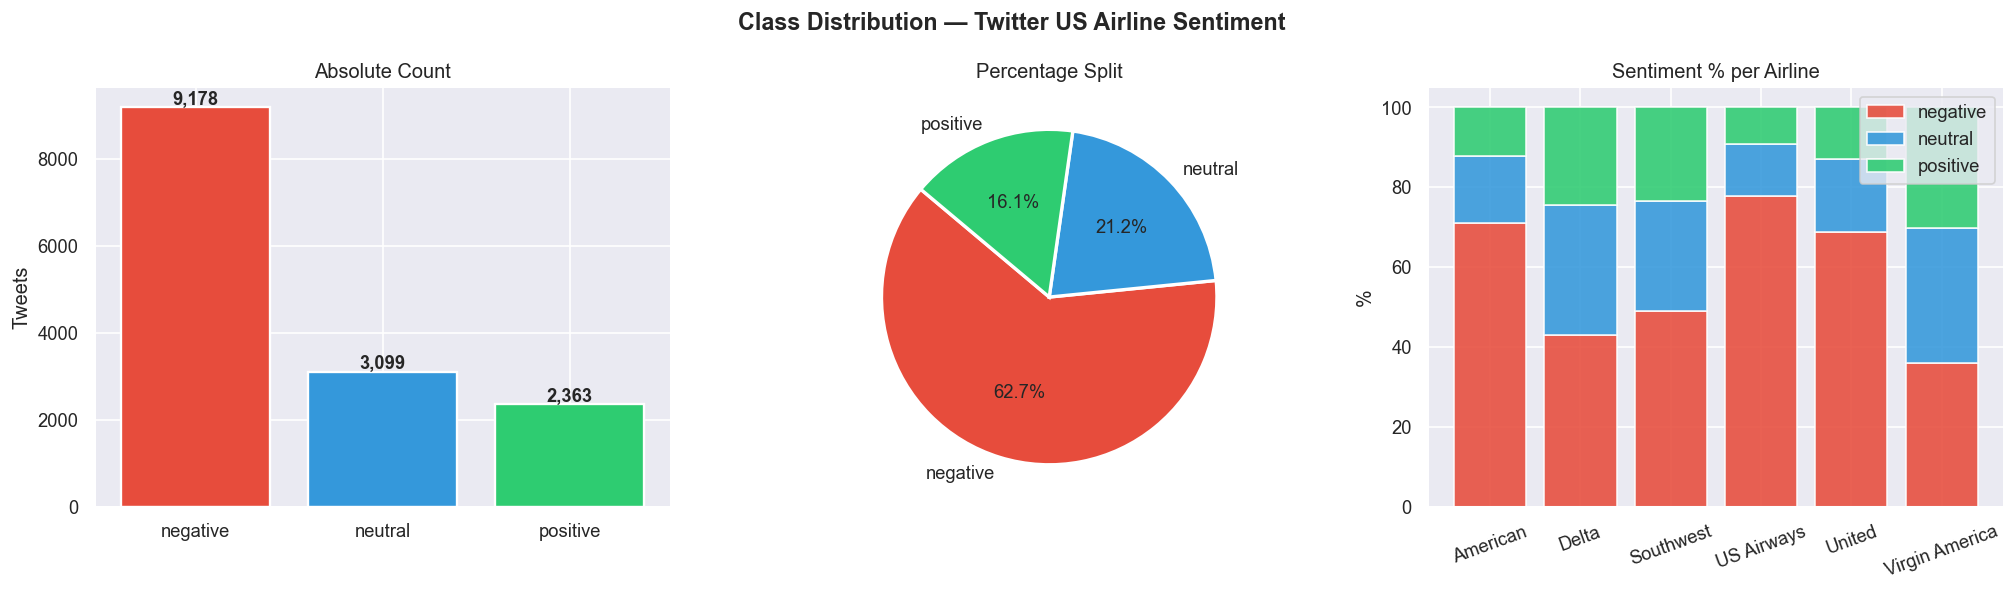

In [3]:
label_counts = df['sentiment'].value_counts().reindex(LABELS)
label_pct    = label_counts / label_counts.sum() * 100
imbalance    = label_counts.max() / label_counts.min()

print('Class distribution:')
for lbl in LABELS:
    bar = 'x' * int(label_pct[lbl] / 2)
    print(f'  {lbl:<10}: {label_counts[lbl]:>5,}  ({label_pct[lbl]:5.1f}%)  {bar}')
print(f'\nImbalance ratio (negative / positive): {imbalance:.2f}x')
print('ACTION: Class imbalance > 3x  use weighted CrossEntropyLoss in training')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Class Distribution — Twitter US Airline Sentiment', fontsize=14, fontweight='bold')

colors = [PALETTE[l] for l in LABELS]
axes[0].bar(LABELS, label_counts.values, color=colors, edgecolor='white', linewidth=1.4)
axes[0].set_title('Absolute Count')
axes[0].set_ylabel('Tweets')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 60, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=LABELS, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Percentage Split')

airline_sent = (df.groupby(['airline', 'sentiment'])
                  .size().unstack(fill_value=0).reindex(columns=LABELS))
airline_pct  = airline_sent.div(airline_sent.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(airline_pct))
for lbl in LABELS:
    axes[2].bar(airline_pct.index, airline_pct[lbl], bottom=bottom,
                label=lbl, color=PALETTE[lbl], alpha=0.88, edgecolor='white')
    bottom += airline_pct[lbl].values
axes[2].set_title('Sentiment % per Airline')
axes[2].set_ylabel('%')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(loc='upper right')

plt.tight_layout()
save_fig('01_class_distribution.png')
plt.show()

## 3. Text Length Distribution
Sets `max_length` for LSTM and BERT tokenisers.

Word count  median=19  P90=26  P95=27  P99=29  max=36
Char count  median=114  max=186

Suggested LSTM max_length = 27  (covers 95% of tweets)
BERT max_length = 128  (standard; all tweets fit comfortably)


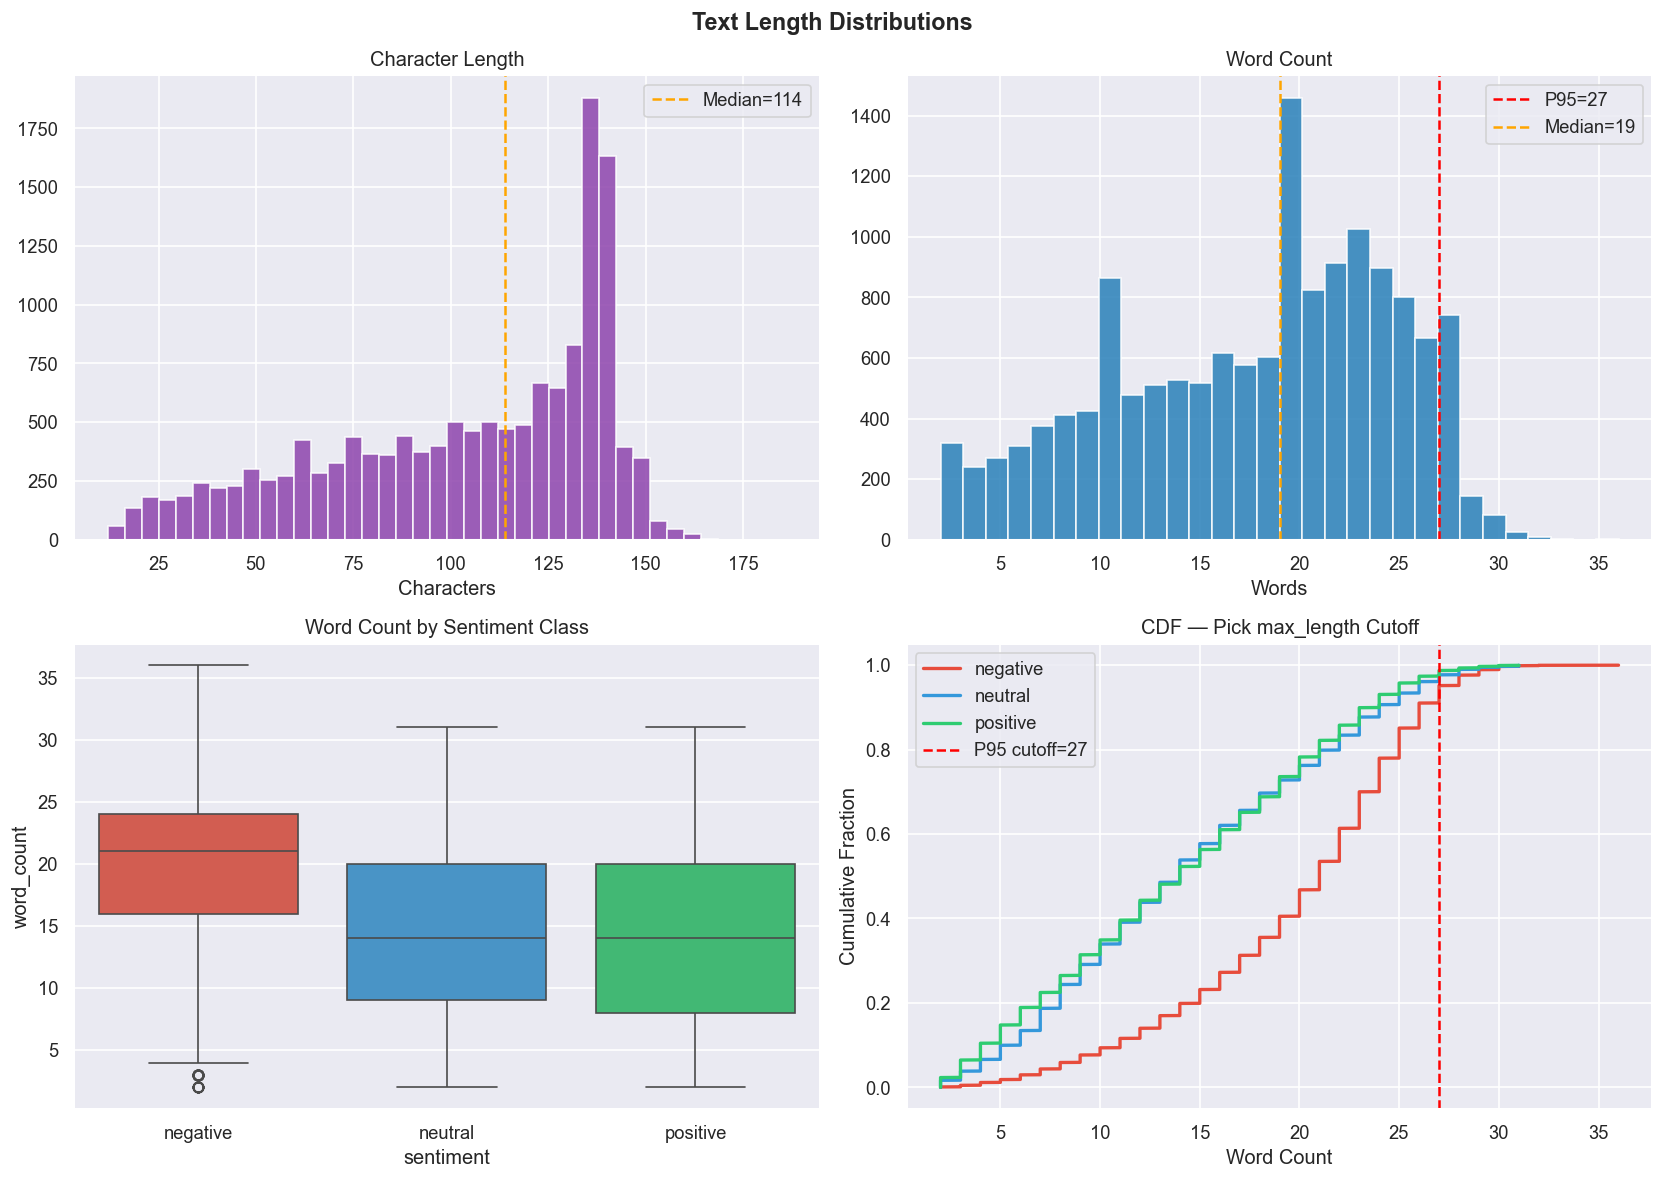

In [4]:
df['char_len']   = df['text'].str.len()
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

p50 = int(df['word_count'].median())
p90 = int(np.percentile(df['word_count'], 90))
p95 = int(np.percentile(df['word_count'], 95))
p99 = int(np.percentile(df['word_count'], 99))

print(f'Word count  median={p50}  P90={p90}  P95={p95}  P99={p99}  max={df["word_count"].max()}')
print(f'Char count  median={int(df["char_len"].median())}  max={df["char_len"].max()}')
print(f'\nSuggested LSTM max_length = {p95}  (covers 95% of tweets)')
print(f'BERT max_length = 128  (standard; all tweets fit comfortably)')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Text Length Distributions', fontsize=14, fontweight='bold')

axes[0,0].hist(df['char_len'], bins=40, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['char_len'].median(), color='orange', linestyle='--',
                   label=f'Median={int(df["char_len"].median())}')
axes[0,0].set_title('Character Length')
axes[0,0].set_xlabel('Characters')
axes[0,0].legend()

axes[0,1].hist(df['word_count'], bins=30, color='#2980b9', edgecolor='white', alpha=0.85)
axes[0,1].axvline(p95, color='red',    linestyle='--', label=f'P95={p95}')
axes[0,1].axvline(p50, color='orange', linestyle='--', label=f'Median={p50}')
axes[0,1].set_title('Word Count')
axes[0,1].set_xlabel('Words')
axes[0,1].legend()

sns.boxplot(data=df, x='sentiment', y='word_count',
            order=LABELS, palette=PALETTE, ax=axes[1,0])
axes[1,0].set_title('Word Count by Sentiment Class')

for lbl in LABELS:
    sw = np.sort(df[df['sentiment'] == lbl]['word_count'].values)
    axes[1,1].plot(sw, np.arange(len(sw)) / len(sw),
                   label=lbl, color=PALETTE[lbl], linewidth=2)
axes[1,1].axvline(p95, color='red', linestyle='--', label=f'P95 cutoff={p95}')
axes[1,1].set_title('CDF — Pick max_length Cutoff')
axes[1,1].set_xlabel('Word Count')
axes[1,1].set_ylabel('Cumulative Fraction')
axes[1,1].legend()

plt.tight_layout()
save_fig('02_text_length_distribution.png')
plt.show()

## 4. Vocabulary Coverage & OOV Risk
Determines LSTM vocabulary size. Always built from training data only.

Total unique tokens     : 9,724
Total token occurrences : 219,088

OOV risk at different frequency thresholds:
  freq <=  1 : 4,310 words  (44.3% of vocab  these map to <UNK>)
  freq <=  3 : 6,404 words  (65.9% of vocab  these map to <UNK>)
  freq <=  5 : 7,234 words  (74.4% of vocab  these map to <UNK>)
  freq <= 10 : 8,041 words  (82.7% of vocab  these map to <UNK>)


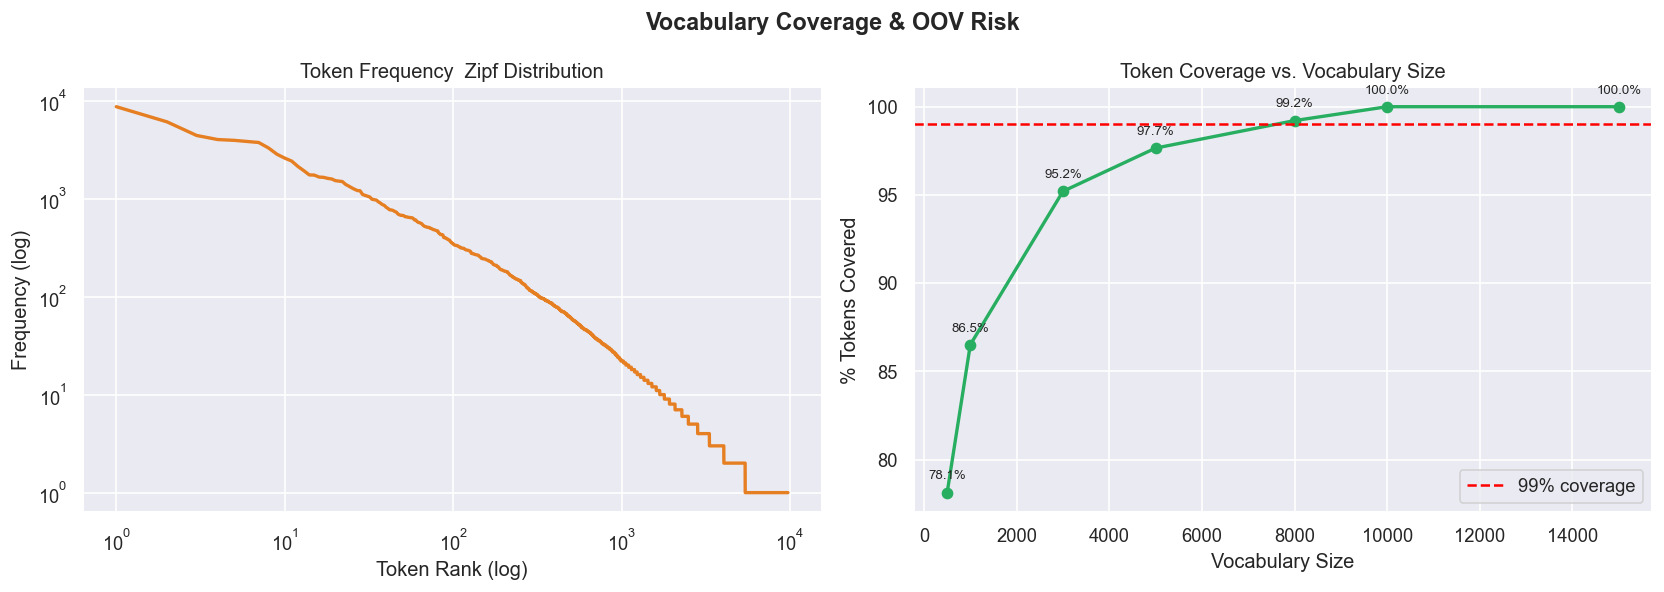


Recommended LSTM vocab size: 8,000 (achieves 99% token coverage)


In [5]:
def tokenise(text):
    """Strips URLs, @mentions, hashtags then returns lowercase word tokens."""
    text = re.sub(r'http\S+|@\w+|#\w+', '', str(text).lower())
    return re.findall(r'\b[a-z]{2,}\b', text)

all_tokens  = [tok for text in df['text'] for tok in tokenise(text)]
freq_dist   = collections.Counter(all_tokens)
total_vocab = len(freq_dist)

print(f'Total unique tokens     : {total_vocab:,}')
print(f'Total token occurrences : {len(all_tokens):,}\n')
print('OOV risk at different frequency thresholds:')
for thresh in [1, 3, 5, 10]:
    rare = sum(1 for _, c in freq_dist.items() if c <= thresh)
    print(f'  freq <= {thresh:2d} : {rare:>5,} words  ({rare/total_vocab*100:.1f}% of vocab  these map to <UNK>)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vocabulary Coverage & OOV Risk', fontsize=14, fontweight='bold')

freqs = sorted(freq_dist.values(), reverse=True)
axes[0].loglog(range(1, len(freqs)+1), freqs, color='#e67e22', linewidth=2)
axes[0].set_title('Token Frequency  Zipf Distribution')
axes[0].set_xlabel('Token Rank (log)')
axes[0].set_ylabel('Frequency (log)')

vocab_sizes = [500, 1000, 3000, 5000, 8000, 10000, 15000]
coverage = []
for vs in vocab_sizes:
    top = set(tok for tok, _ in freq_dist.most_common(vs))
    coverage.append(sum(1 for t in all_tokens if t in top) / len(all_tokens) * 100)

axes[1].plot(vocab_sizes, coverage, marker='o', color='#27ae60', linewidth=2)
axes[1].axhline(99, color='red', linestyle='--', label='99% coverage')
for vs, cov in zip(vocab_sizes, coverage):
    axes[1].annotate(f'{cov:.1f}%', (vs, cov), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)
axes[1].set_title('Token Coverage vs. Vocabulary Size')
axes[1].set_xlabel('Vocabulary Size')
axes[1].set_ylabel('% Tokens Covered')
axes[1].legend()

plt.tight_layout()
save_fig('03_vocabulary_coverage.png')
plt.show()

rec_vocab = next((vs for vs, cov in zip(vocab_sizes, coverage) if cov >= 99), 15000)
print(f'\nRecommended LSTM vocab size: {rec_vocab:,} (achieves 99% token coverage)')

## 5. Top N-grams per Sentiment Class
Reveals genuinely predictive words and confirms label quality.

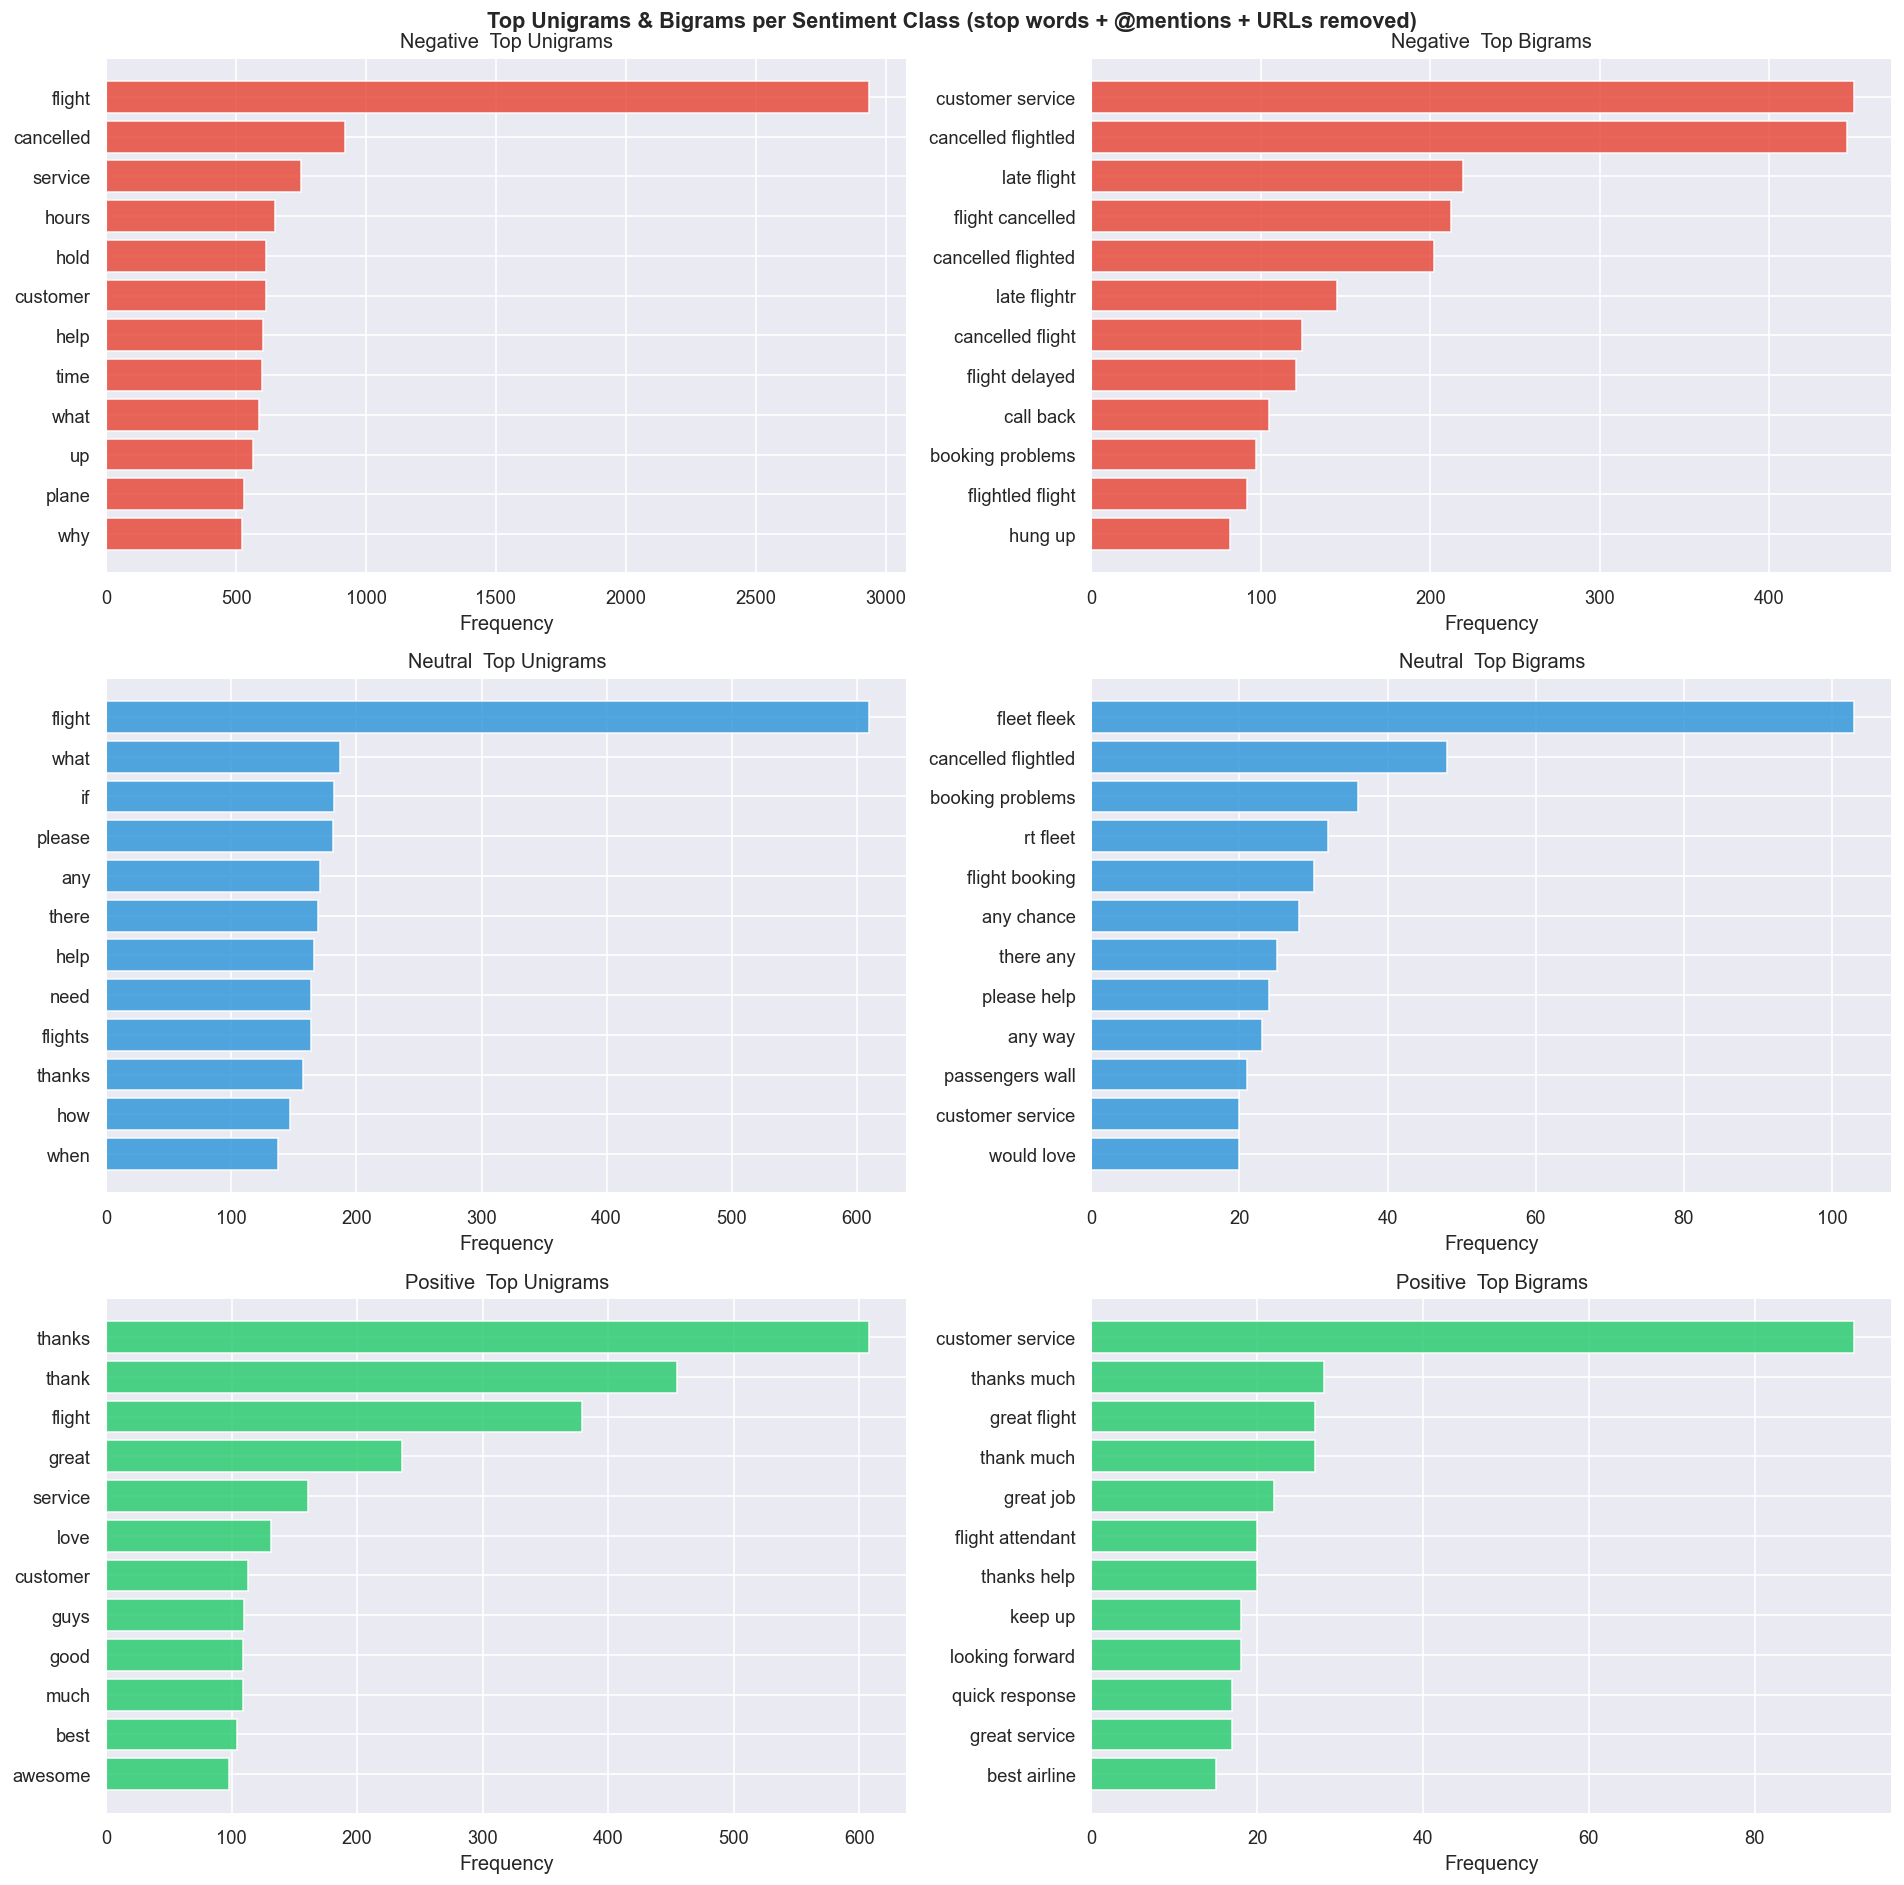

In [6]:
STOP = {'the','a','an','is','it','this','and','to','i','of','in','my','was','for',
        'with','be','not','are','on','at','have','do','its','so','but','that','or',
        'as','by','from','all','been','has','had','will','im','just','get','us',
        'me','we','you','your','our','they','their','am','can','got','now','no'}

def top_ngrams(texts, n=1, top_k=12):
    ngrams = []
    for text in texts:
        tokens = [t for t in tokenise(text) if t not in STOP]
        for i in range(len(tokens) - n + 1):
            ngrams.append(' '.join(tokens[i:i+n]))
    return collections.Counter(ngrams).most_common(top_k)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle('Top Unigrams & Bigrams per Sentiment Class (stop words + @mentions + URLs removed)',
             fontsize=13, fontweight='bold')

for row, label in enumerate(LABELS):
    texts = df[df['sentiment'] == label]['text'].tolist()
    for col, n in enumerate([1, 2]):
        ng = top_ngrams(texts, n=n)
        if not ng:
            continue
        words, counts = zip(*ng)
        ypos = range(len(words))
        axes[row, col].barh(list(ypos), list(counts),
                             color=PALETTE[label], alpha=0.85, edgecolor='white')
        axes[row, col].set_yticks(list(ypos))
        axes[row, col].set_yticklabels(list(words))
        axes[row, col].invert_yaxis()
        axes[row, col].set_title(
            f"{label.capitalize()}  Top {'Unigrams' if n==1 else 'Bigrams'}")
        axes[row, col].set_xlabel('Frequency')

plt.tight_layout()
save_fig('04_top_ngrams.png')
plt.show()

## 6. Negative Reason Analysis
Unique to this dataset — unpacks *why* tweets are negative, useful for model error analysis.

Negative tweets total : 9,178
With labelled reason  : 9,178

  Customer Service Issue             : 2,910  (31.7%)
  Late Flight                        : 1,665  (18.1%)
  Can't Tell                         : 1,190  (13.0%)
  Cancelled Flight                   :  847  (9.2%)
  Lost Luggage                       :  724  (7.9%)
  Bad Flight                         :  580  (6.3%)
  Flight Booking Problems            :  529  (5.8%)
  Flight Attendant Complaints        :  481  (5.2%)
  longlines                          :  178  (1.9%)
  Damaged Luggage                    :   74  (0.8%)


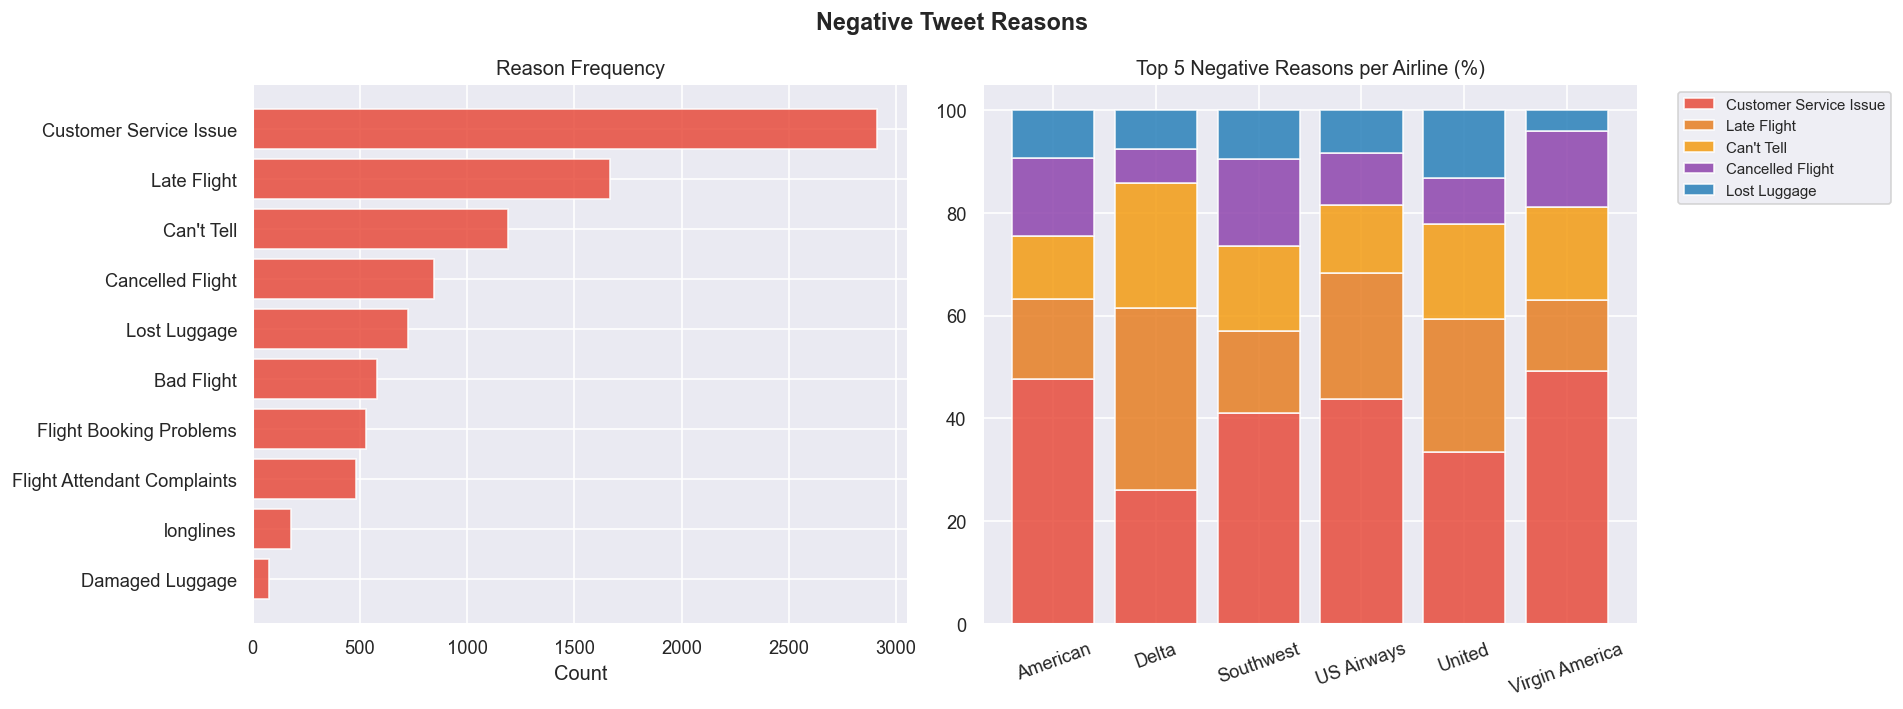

In [7]:
neg_df      = df[df['sentiment'] == 'negative'].copy()
neg_reasons = neg_df['negativereason'].value_counts().dropna()

print(f'Negative tweets total : {len(neg_df):,}')
print(f'With labelled reason  : {neg_df["negativereason"].notna().sum():,}')
print()
for reason, cnt in neg_reasons.items():
    print(f'  {reason:<35}: {cnt:>4,}  ({cnt/len(neg_df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Negative Tweet Reasons', fontsize=14, fontweight='bold')

axes[0].barh(neg_reasons.index[::-1], neg_reasons.values[::-1],
             color='#e74c3c', alpha=0.85, edgecolor='white')
axes[0].set_title('Reason Frequency')
axes[0].set_xlabel('Count')

top5 = neg_reasons.head(5).index.tolist()
ar   = (neg_df[neg_df['negativereason'].isin(top5)]
         .groupby(['airline', 'negativereason']).size().unstack(fill_value=0)
         .reindex(columns=top5))
ar_pct  = ar.div(ar.sum(axis=1), axis=0) * 100
bottom  = np.zeros(len(ar_pct))
r_colors = ['#e74c3c','#e67e22','#f39c12','#8e44ad','#2980b9']
for i, reason in enumerate(top5):
    axes[1].bar(ar_pct.index, ar_pct[reason], bottom=bottom,
                label=reason, color=r_colors[i], alpha=0.85, edgecolor='white')
    bottom += ar_pct[reason].values
axes[1].set_title('Top 5 Negative Reasons per Airline (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
save_fig('05_negative_reasons.png')
plt.show()

## 7. Confidence Score & Temporal Analysis

Low confidence labels (<0.7) : 3,872  (26.4%)  consider filtering in Stage 3
Date range : 2015-02-17 to 2015-02-24


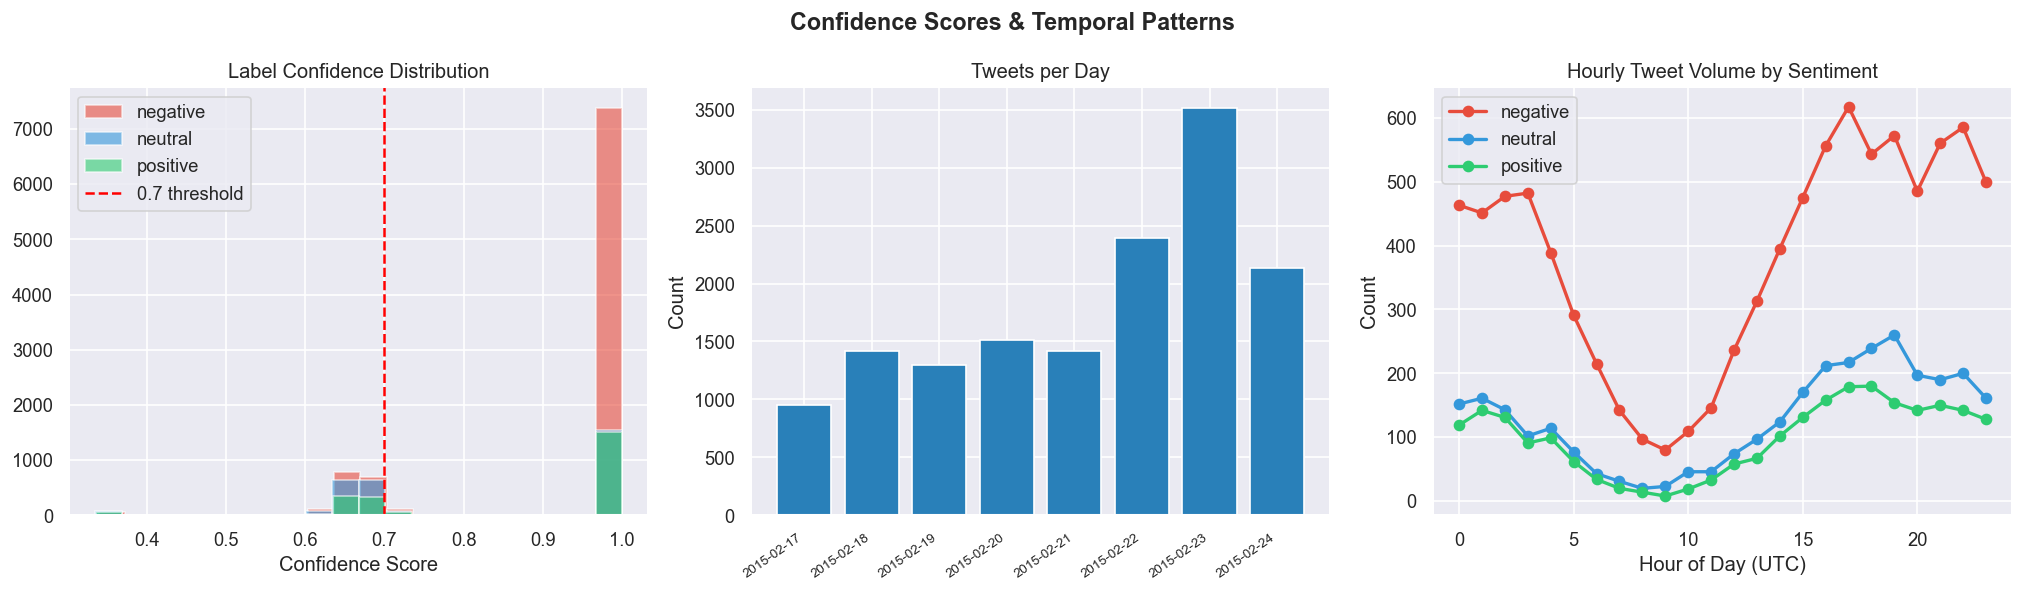

In [8]:
df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=True)
df['date']          = df['tweet_created'].dt.date
df['hour']          = df['tweet_created'].dt.hour

low_conf = (df['airline_sentiment_confidence'] < 0.7).sum()
print(f'Low confidence labels (<0.7) : {low_conf:,}  ({low_conf/len(df)*100:.1f}%)  consider filtering in Stage 3')
print(f'Date range : {df["tweet_created"].min().date()} to {df["tweet_created"].max().date()}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Confidence Scores & Temporal Patterns', fontsize=14, fontweight='bold')

for lbl in LABELS:
    axes[0].hist(df[df['sentiment']==lbl]['airline_sentiment_confidence'],
                 bins=20, alpha=0.6, label=lbl, color=PALETTE[lbl], edgecolor='white')
axes[0].axvline(0.7, color='red', linestyle='--', label='0.7 threshold')
axes[0].set_title('Label Confidence Distribution')
axes[0].set_xlabel('Confidence Score')
axes[0].legend()

daily = df.groupby('date').size()
axes[1].bar(range(len(daily)), daily.values, color='#2980b9', edgecolor='white')
axes[1].set_xticks(range(len(daily)))
axes[1].set_xticklabels([str(d) for d in daily.index], rotation=35, ha='right', fontsize=8)
axes[1].set_title('Tweets per Day')
axes[1].set_ylabel('Count')

hourly = df.groupby(['hour','sentiment']).size().unstack(fill_value=0).reindex(columns=LABELS)
for lbl in LABELS:
    axes[2].plot(hourly.index, hourly[lbl], marker='o',
                 label=lbl, color=PALETTE[lbl], linewidth=2)
axes[2].set_title('Hourly Tweet Volume by Sentiment')
axes[2].set_xlabel('Hour of Day (UTC)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
save_fig('06_confidence_temporal.png')
plt.show()

## 8. Duplicate Detection & Data Quality

In [9]:
exact_dups     = df.duplicated(subset=['text']).sum()
id_dups        = df.duplicated(subset=['tweet_id']).sum()
label_conflict = (df.groupby('text')['sentiment'].nunique() > 1).sum()
low_conf_rows  = (df['airline_sentiment_confidence'] < 0.7).sum()

print(f'Total rows              : {len(df):,}')
print(f'Duplicate tweet_ids     : {id_dups}')
print(f'Duplicate text (exact)  : {exact_dups}')
print(f'Label conflicts         : {label_conflict}  (same text, different labels)')
print(f'Low confidence (<0.7)   : {low_conf_rows:,}  ({low_conf_rows/len(df)*100:.1f}%)')

df_clean = df.drop_duplicates(subset=['text']).copy()
# Optional: also filter low confidence labels
# df_clean = df_clean[df_clean['airline_sentiment_confidence'] >= 0.7]

print(f'\nClean samples after dedup : {len(df_clean):,}')
print('\nNull counts in clean data (relevant cols):')
print(df_clean[['text','sentiment','airline','negativereason']].isnull().sum())

Total rows              : 14,640
Duplicate tweet_ids     : 155
Duplicate text (exact)  : 213
Label conflicts         : 25  (same text, different labels)
Low confidence (<0.7)   : 3,872  (26.4%)

Clean samples after dedup : 14,427

Null counts in clean data (relevant cols):
text                 0
sentiment            0
airline              0
negativereason    5347
dtype: int64


## 9. Stratified Train / Val / Test Split
**80 / 10 / 10** — stratified by sentiment class.  
Test set is **locked immediately** — never evaluate on it during development.

Saved to:
  (relative) c:\Users\sanje\OneDrive\Desktop\sentiment_api\data\processed
  (absolute) C:\Users\sanje\OneDrive\Desktop\sentiment_api\data\processed
  train.csv      : 11,541
  val.csv        : 1,443
  test.csv       : 1,443
  label_map.json : negative=0, neutral=1, positive=2

Stratification check (class % per split):
  Train : neg=62.9%  neu=21.2%  pos=15.9%
  Val   : neg=62.9%  neu=21.2%  pos=15.9%
  Test  : neg=62.9%  neu=21.2%  pos=15.9%


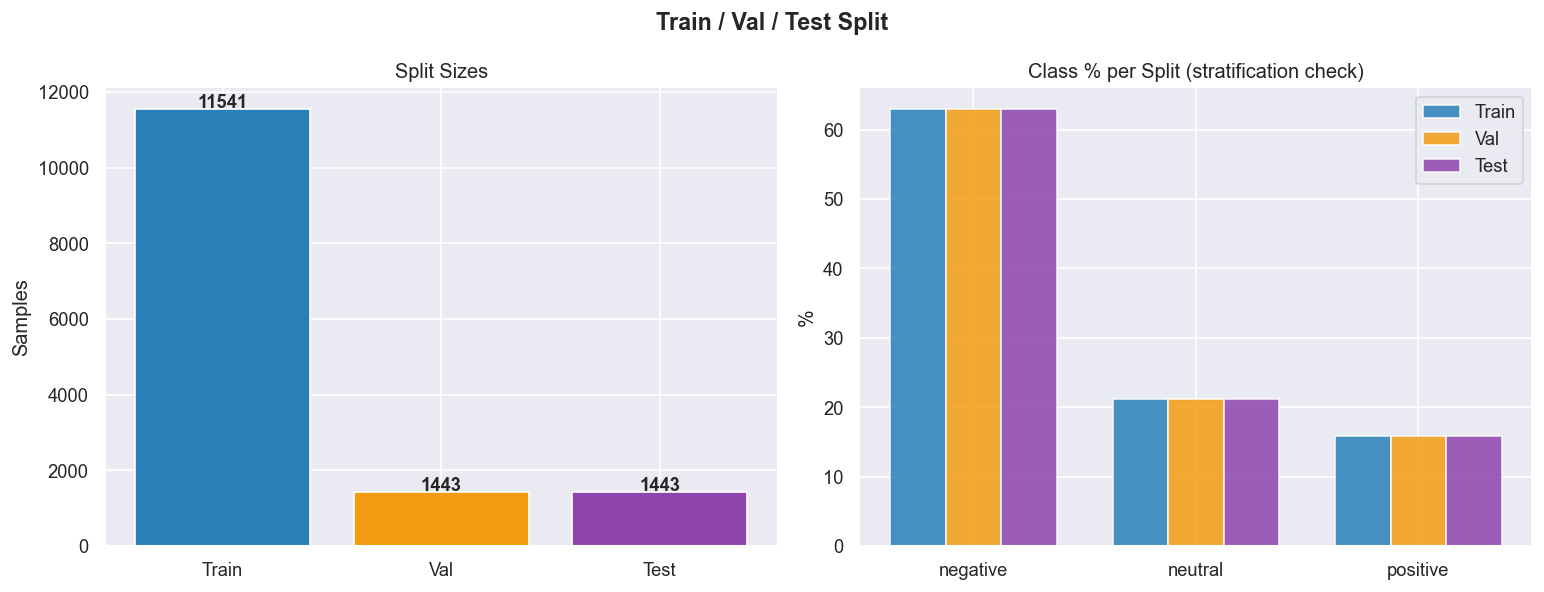

In [10]:
df_clean['label_int'] = df_clean['sentiment'].map(LABEL_MAP)

train_df, temp_df = train_test_split(
    df_clean, test_size=0.20, stratify=df_clean['sentiment'], random_state=42)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['sentiment'], random_state=42)

# Save CSVs
save_csv(train_df, 'train.csv')
save_csv(val_df,   'val.csv')
save_csv(test_df,  'test.csv')

# Save label map for API use
save_json({'label_to_int': LABEL_MAP,
           'int_to_label': {str(v): k for k, v in LABEL_MAP.items()}},
          'label_map.json')

print(f'Saved to:')
print(f'  (relative) {PROCESSED}')
print(f'  (absolute) {PROCESSED_ABS}')
print(f'  train.csv      : {len(train_df):,}')
print(f'  val.csv        : {len(val_df):,}')
print(f'  test.csv       : {len(test_df):,}')
print(f'  label_map.json : negative=0, neutral=1, positive=2')
print()
print('Stratification check (class % per split):')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    d = split['sentiment'].value_counts(normalize=True).mul(100).round(1).reindex(LABELS).to_dict()
    print(f'  {name:<6}: neg={d["negative"]}%  neu={d["neutral"]}%  pos={d["positive"]}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Train / Val / Test Split', fontsize=14, fontweight='bold')

split_sizes = {'Train': len(train_df), 'Val': len(val_df), 'Test': len(test_df)}
axes[0].bar(split_sizes.keys(), split_sizes.values(),
            color=['#2980b9','#f39c12','#8e44ad'], edgecolor='white')
axes[0].set_title('Split Sizes')
axes[0].set_ylabel('Samples')
for i, (k, v) in enumerate(split_sizes.items()):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

x, w = np.arange(3), 0.25
split_colors = ['#2980b9','#f39c12','#8e44ad']
for i, (name, split) in enumerate([('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    vals = [split['sentiment'].value_counts(normalize=True).get(l, 0)*100 for l in LABELS]
    axes[1].bar(x + i*w, vals, w, label=name, alpha=0.85,
                edgecolor='white', color=split_colors[i])
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(LABELS)
axes[1].set_title('Class % per Split (stratification check)')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
save_fig('07_split_distribution.png')
plt.show()

## 10. EDA Summary Report

In [11]:
report = (
    '=' * 62 + '\n'
    '  STAGE 2  EDA REPORT\n'
    '  Dataset: Twitter US Airline Sentiment (Kaggle)\n'
    + '=' * 62 + '\n\n'
    'DATASET OVERVIEW\n'
    f'  Source            : Kaggle  Twitter US Airline Sentiment\n'
    f'  Total raw rows    : {len(df):,}\n'
    f'  Airlines          : {sorted(df["airline"].unique())}\n'
    f'  Duplicate texts   : {exact_dups}\n'
    f'  Label conflicts   : {label_conflict}\n'
    f'  Low conf (<0.7)   : {low_conf_rows:,} ({low_conf_rows/len(df)*100:.1f}%)\n'
    f'  Clean samples     : {len(df_clean):,}\n'
    f'  Date range        : {df["tweet_created"].min().date()} to {df["tweet_created"].max().date()}\n\n'
    'CLASS DISTRIBUTION\n'
    f'  negative  : {label_counts["negative"]:>5,}  ({label_pct["negative"]:.1f}%)\n'
    f'  neutral   : {label_counts["neutral"]:>5,}  ({label_pct["neutral"]:.1f}%)\n'
    f'  positive  : {label_counts["positive"]:>5,}  ({label_pct["positive"]:.1f}%)\n'
    f'  Imbalance ratio   : {imbalance:.2f}x\n'
    f'  ACTION            : Use class-weighted CrossEntropyLoss\n\n'
    'TEXT LENGTH STATS\n'
    f'  Word count  median={p50}  P95={p95}  P99={p99}\n'
    f'  LSTM max_length   : {p95} tokens\n'
    f'  BERT max_length   : 128 (all tweets fit)\n\n'
    'VOCABULARY\n'
    f'  Unique tokens     : {total_vocab:,}\n'
    f'  Recommended vocab : {rec_vocab:,} (99% coverage)\n'
    f'  Note              : strip @mentions + URLs before building vocab\n\n'
    'SPLITS  data/processed/\n'
    f'  train.csv  : {len(train_df):,} (80%)\n'
    f'  val.csv    : {len(val_df):,} (10%)\n'
    f'  test.csv   : {len(test_df):,} (10%)\n'
    f'  label_map  : negative=0  neutral=1  positive=2\n\n'
    'FIGURES  data/processed/eda_figures/\n'
    '  01_class_distribution.png\n'
    '  02_text_length_distribution.png\n'
    '  03_vocabulary_coverage.png\n'
    '  04_top_ngrams.png\n'
    '  05_negative_reasons.png\n'
    '  06_confidence_temporal.png\n'
    '  07_split_distribution.png\n\n'
    'STAGE 3 ACTION ITEMS\n'
    '  1. Strip @mentions, URLs, hashtags\n'
    '  2. Convert emojis to text tokens (strong signal)\n'
    '  3. Expand contractions for LSTM path\n'
    f'  4. Build LSTM vocab from train.csv only  size {rec_vocab:,}\n'
    f'  5. LSTM max_length={p95}  |  BERT max_length=128\n'
    '  6. Class weights = inverse frequency (neg:neu:pos ~ 1:3:4)\n'
    + '=' * 62
)

# Save report to both locations
with open(REPORT_PATH, 'w') as f:
    f.write(report)
try:
    with open(os.path.join(PROCESSED_ABS, 'eda_report.txt'), 'w') as f:
        f.write(report)
except Exception as e:
    print(f'[abs path skipped] {e}')

print(report)
print(f'\nReport saved to:')
print(f'  {REPORT_PATH}')
print(f'  {os.path.join(PROCESSED_ABS, "eda_report.txt")}')


  STAGE 2  EDA REPORT
  Dataset: Twitter US Airline Sentiment (Kaggle)

DATASET OVERVIEW
  Source            : Kaggle  Twitter US Airline Sentiment
  Total raw rows    : 14,640
  Airlines          : ['American', 'Delta', 'Southwest', 'US Airways', 'United', 'Virgin America']
  Duplicate texts   : 213
  Label conflicts   : 25
  Low conf (<0.7)   : 3,872 (26.4%)
  Clean samples     : 14,427
  Date range        : 2015-02-17 to 2015-02-24

CLASS DISTRIBUTION
  negative  : 9,178  (62.7%)
  neutral   : 3,099  (21.2%)
  positive  : 2,363  (16.1%)
  Imbalance ratio   : 3.88x
  ACTION            : Use class-weighted CrossEntropyLoss

TEXT LENGTH STATS
  Word count  median=19  P95=27  P99=29
  LSTM max_length   : 27 tokens
  BERT max_length   : 128 (all tweets fit)

VOCABULARY
  Unique tokens     : 9,724
  Recommended vocab : 8,000 (99% coverage)
  Note              : strip @mentions + URLs before building vocab

SPLITS  data/processed/
  train.csv  : 11,541 (80%)
  val.csv    : 1,443 (10%)
  te

---
## Stage 2 Complete

| Output | Location |
|---|---|
| `train.csv` | `data/processed/train.csv` |
| `val.csv` | `data/processed/val.csv` |
| `test.csv` | `data/processed/test.csv` |
| `label_map.json` | `data/processed/label_map.json` |
| 7 EDA charts | `data/processed/eda_figures/` |
| `eda_report.txt` | `data/processed/eda_report.txt` |

**Proceed to Stage 3: Preprocessing & Feature Engineering**